# 🫁 흉부 X-ray 폐렴 분류 (NORMAL vs PNEUMONIA)

**데이콘 · 오즈코딩 AI 헬스케어 딥러닝 트랙 해커톤**

| 단계 | 내용 |
|---|---|
| 1 | 환경 설정 & 라이브러리 |
| 2 | 데이터 로드 & EDA (클래스 분포, 이미지 크기, 샘플 시각화) |
| 3 | Dataset / Augmentation |
| 4 | 모델: ImageNet 사전학습 **EfficientNet-B0** 전이학습 |
| 5 | 학습: Stratified K-Fold, AMP, Cosine LR, Early Stopping, 클래스 가중치 |
| 6 | 검증: Confusion Matrix · ROC-AUC · F1 · **Threshold 튜닝** |
| 7 | 추론: Fold 앙상블 + TTA → `submission.csv` |
| 8 | 해석: **Grad-CAM** 으로 모델이 본 영역 확인 |

> **핵심 포인트**
> - 학습 데이터는 폐렴:정상 ≈ 3:1로 **불균형** → 클래스 가중치 + threshold 튜닝으로 대응
> - 이 데이터(Kermany et al. 소아 흉부 X-ray)는 학습/테스트 분포 차이가 있어 모델이 폐렴을 **과잉 예측**하기 쉬움 → 0.5 고정 대신 검증셋 기준 threshold 사용
> - GPU 환경(Colab 등) 권장. `CFG`만 바꾸면 모델·해상도·폴드 수 조정 가능

## 1. 환경 설정

In [ ]:
!pip install -q timm opencv-python-headless scikit-learn

import os, random, time, copy, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| device:', DEVICE)

torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

class CFG:
    # ---- 경로 (환경에 맞게 수정) ----
    DATA_DIR  = '/content/drive/MyDrive/ai 헬스케어 7기/미니프로젝트 2/해커톤2/'
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    TEST_DIR  = os.path.join(DATA_DIR, 'test')
    OUT_DIR   = './outputs'

    # ---- 모델 / 학습 ----
    MODEL_NAME  = 'efficientnet_b0'      # 'efficientnet_b0' | 'resnet50' | 'convnext_tiny' | 'densenet121'
    IMG_SIZE    = 384
    BATCH_SIZE  = 32
    EPOCHS      = 15
    LR          = 3e-4
    WEIGHT_DECAY= 1e-4
    PATIENCE    = 4                      # early stopping
    LABEL_SMOOTHING = 0.05

    N_FOLDS     = 5                      # 1이면 단일 holdout(검증 15%)로 빠르게 실험
    RUN_FOLDS   = None                   # 예: [0] 만 돌리고 싶으면 [0], None이면 전체
    VAL_RATIO   = 0.15                   # N_FOLDS == 1 일 때만 사용

    USE_TTA     = True
    NUM_WORKERS = 2
    SEED        = 42

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(CFG.SEED)

Mounted at /content/drive


## 2. 데이터 로드 & EDA

In [ ]:
train_df = pd.read_csv(os.path.join(CFG.DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(CFG.DATA_DIR, 'test.csv'))
sub_df   = pd.read_csv(os.path.join(CFG.DATA_DIR, 'sample_submission.csv'))

train_df['path'] = train_df['file_name'].apply(lambda f: os.path.join(CFG.TRAIN_DIR, f))
test_df['path']  = test_df['file_name'].apply(lambda f: os.path.join(CFG.TEST_DIR, f))

print('train:', train_df.shape, '| test:', test_df.shape)
print('\n[라벨 분포]')
print(train_df['label'].value_counts().rename({0: 'NORMAL(0)', 1: 'PNEUMONIA(1)'}))
print('\n폐렴 비율: {:.1%}'.format(train_df['label'].mean()))
assert train_df['path'].apply(os.path.exists).all(), '학습 이미지 경로를 확인하세요 (CFG.DATA_DIR)'
display(train_df.head())

train: (5216, 3) | test: (624, 2)

[라벨 분포]
label
PNEUMONIA(1)    3875
NORMAL(0)       1341
Name: count, dtype: int64

폐렴 비율: 74.3%


,file_name,label,path
0,train_0001.png,0,/content/drive/MyDrive/ai 헬스케어 7기/미니프로젝트 2/해커톤...
1,train_0002.png,0,/content/drive/MyDrive/ai 헬스케어 7기/미니프로젝트 2/해커톤...
2,train_0003.png,0,/content/drive/MyDrive/ai 헬스케어 7기/미니프로젝트 2/해커톤...
3,train_0004.png,0,/content/drive/MyDrive/ai 헬스케어 7기/미니프로젝트 2/해커톤...
4,train_0005.png,0,/content/drive/MyDrive/ai 헬스케어 7기/미니프로젝트 2/해커톤...


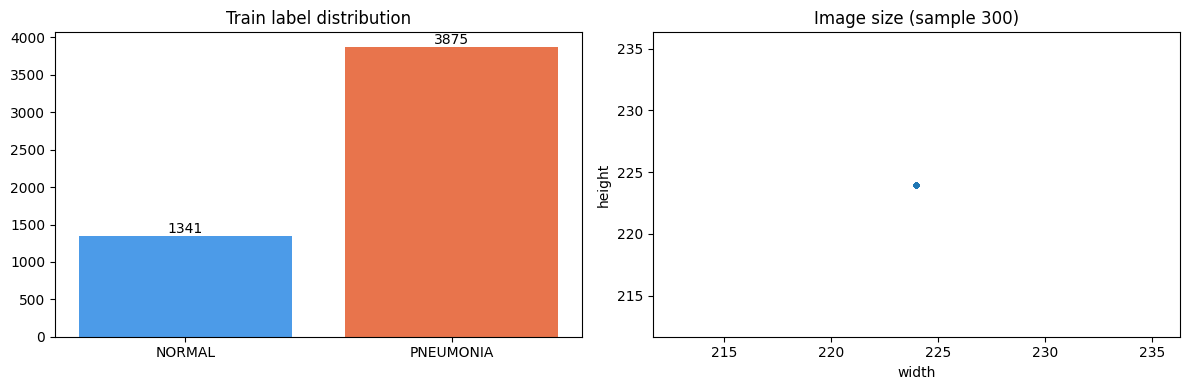

height  mean/min/max: 224.0 224 224
width   mean/min/max: 224.0 224 224


In [ ]:
# 클래스 분포 & 이미지 크기 분포 (샘플 300장)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts = train_df['label'].value_counts().sort_index()
ax[0].bar(['NORMAL', 'PNEUMONIA'], counts.values, color=['#4C9BE8', '#E8744C'])
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha='center', va='bottom')
ax[0].set_title('Train label distribution')

sizes = []
for p in train_df.sample(300, random_state=CFG.SEED)['path']:
    im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    sizes.append(im.shape)
sizes = np.array(sizes)
ax[1].scatter(sizes[:, 1], sizes[:, 0], s=8, alpha=0.5)
ax[1].set_xlabel('width'); ax[1].set_ylabel('height'); ax[1].set_title('Image size (sample 300)')
plt.tight_layout(); plt.show()
print('height  mean/min/max:', sizes[:, 0].mean().round(), sizes[:, 0].min(), sizes[:, 0].max())
print('width   mean/min/max:', sizes[:, 1].mean().round(), sizes[:, 1].min(), sizes[:, 1].max())

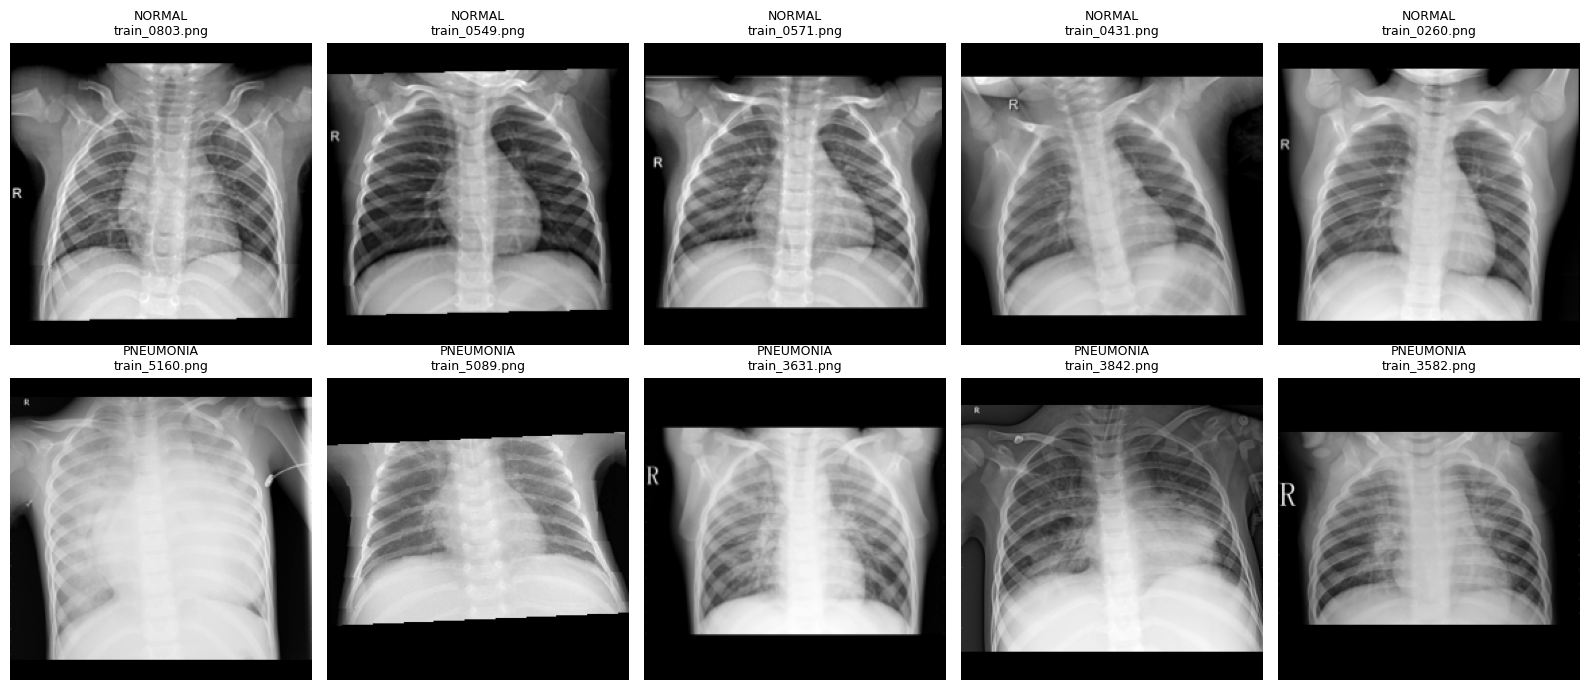

In [ ]:
# 샘플 이미지
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for row, lbl in enumerate([0, 1]):
    samples = train_df[train_df.label == lbl].sample(5, random_state=CFG.SEED)
    for col, (_, r) in enumerate(samples.iterrows()):
        axes[row, col].imshow(cv2.imread(r.path, cv2.IMREAD_GRAYSCALE), cmap='gray')
        axes[row, col].set_title(f"{['NORMAL','PNEUMONIA'][lbl]}\n{r.file_name}", fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout(); plt.show()

## 3. Dataset & Augmentation

- X-ray는 흑백 → 3채널로 복제해 ImageNet 사전학습 가중치 활용
- **CLAHE**(대비 제한 히스토그램 평활화)로 폐 음영 대비 강화
- Augmentation은 의료영상 특성상 **과하지 않게**: 소폭 회전/이동/확대, 밝기·대비 변화
  - 좌우 반전은 심장 위치가 바뀌므로 학습에서는 사용하지 않음 (TTA에서도 제외)

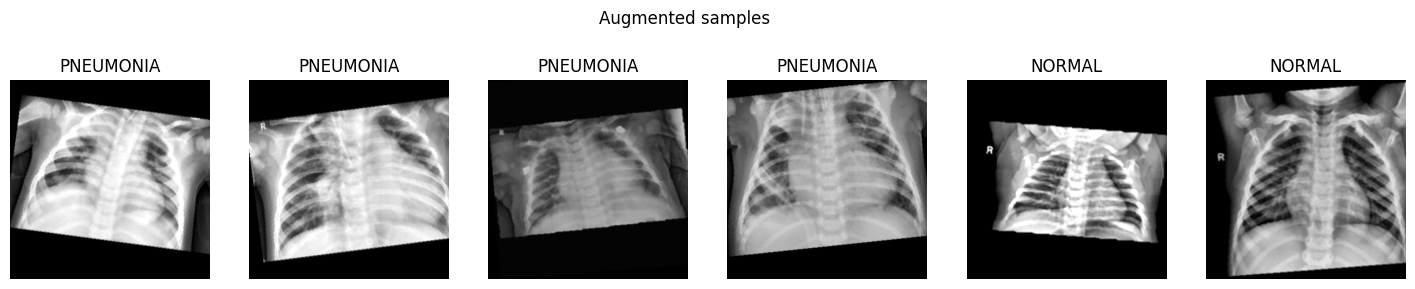

In [ ]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def load_xray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = _clahe.apply(img)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)   # (H, W, 3) uint8

train_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.RandomAffine(degrees=10, translate=(0.06, 0.06), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
valid_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# TTA: 원본 + 약간 확대(center crop 후 resize)
tta_zoom_tf = T.Compose([
    T.ToPILImage(),
    T.Resize((int(CFG.IMG_SIZE * 1.1), int(CFG.IMG_SIZE * 1.1))),
    T.CenterCrop(CFG.IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XrayDataset(Dataset):
    def __init__(self, df, transform, has_label=True):
        self.paths = df['path'].values
        self.labels = df['label'].values if has_label else None
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = self.transform(load_xray(self.paths[i]))
        if self.labels is None:
            return img
        return img, torch.tensor(self.labels[i], dtype=torch.long)

# 증강 결과 확인
_ds = XrayDataset(train_df.sample(6, random_state=0), train_tf)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, (x, y) in zip(axes, [_ds[i] for i in range(6)]):
    img = x.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    ax.imshow(np.clip(img, 0, 1)); ax.set_title(['NORMAL', 'PNEUMONIA'][y.item()]); ax.axis('off')
plt.suptitle('Augmented samples'); plt.show()

## 4. 모델 (ImageNet 사전학습 전이학습)

In [ ]:
def build_model(name=CFG.MODEL_NAME, num_classes=2, pretrained=True):
    W = 'DEFAULT' if pretrained else None
    if name == 'efficientnet_b0':
        m = torchvision.models.efficientnet_b0(weights=W)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif name == 'resnet50':
        m = torchvision.models.resnet50(weights=W)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == 'convnext_tiny':
        m = torchvision.models.convnext_tiny(weights=W)
        m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)
    elif name == 'densenet121':   # CheXNet 계열에서 자주 쓰는 백본
        m = torchvision.models.densenet121(weights=W)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    else:
        raise ValueError(name)
    return m

_m = build_model()
print(CFG.MODEL_NAME, '| params: {:.2f}M'.format(sum(p.numel() for p in _m.parameters()) / 1e6))
del _m

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


efficientnet_b0 | params: 4.01M


## 5. 학습

- **Loss**: 클래스 가중치(역빈도) + Label smoothing CrossEntropy
- **Optimizer**: AdamW / **Scheduler**: 1 epoch warmup + Cosine
- **AMP**(mixed precision)로 GPU 메모리·속도 개선
- 폴드별 **best val AUC** 가중치 저장, OOF 예측 확률 수집 → threshold 튜닝에 사용

In [ ]:
def get_loaders(tr_df, va_df):
    tr_loader = DataLoader(XrayDataset(tr_df, train_tf), batch_size=CFG.BATCH_SIZE, shuffle=True,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
    va_loader = DataLoader(XrayDataset(va_df, valid_tf), batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                           num_workers=CFG.NUM_WORKERS, pin_memory=True)
    return tr_loader, va_loader

def make_criterion(labels):
    counts = np.bincount(labels, minlength=2)
    w = counts.sum() / (2 * counts)                       # 역빈도 가중치
    print(f'  class weights: NORMAL={w[0]:.3f}, PNEUMONIA={w[1]:.3f}')
    return nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE),
                               label_smoothing=CFG.LABEL_SMOOTHING)

def make_scheduler(optimizer, steps_per_epoch):
    total, warm = CFG.EPOCHS * steps_per_epoch, steps_per_epoch
    def lr_lambda(step):
        if step < warm:
            return (step + 1) / warm
        prog = (step - warm) / max(1, total - warm)
        return 0.5 * (1 + np.cos(np.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler):
    model.train(); total_loss, n = 0.0, 0
    for x, y in tqdm(loader, leave=False, desc='train'):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            loss = criterion(model(x), y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        total_loss += loss.item() * x.size(0); n += x.size(0)
    return total_loss / n

@torch.no_grad()
def predict_proba(model, loader, has_label=True):
    model.eval(); probs, ys = [], []
    for batch in tqdm(loader, leave=False, desc='infer'):
        x = batch[0] if has_label else batch
        with torch.autocast(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda')):
            logits = model(x.to(DEVICE, non_blocking=True))
        probs.append(F.softmax(logits.float(), dim=1)[:, 1].cpu().numpy())
        if has_label: ys.append(batch[1].numpy())
    probs = np.concatenate(probs)
    return (probs, np.concatenate(ys)) if has_label else probs

def run_fold(fold, tr_df, va_df):
    print(f'\n========== Fold {fold} | train {len(tr_df)} / valid {len(va_df)} ==========')
    tr_loader, va_loader = get_loaders(tr_df, va_df)
    model = build_model().to(DEVICE)
    criterion = make_criterion(tr_df['label'].values)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = make_scheduler(optimizer, len(tr_loader))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    best_auc, best_state, bad, hist = -1, None, 0, []
    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, tr_loader, criterion, optimizer, scheduler, scaler)
        va_prob, va_y = predict_proba(model, va_loader)
        va_loss = F.binary_cross_entropy(torch.tensor(va_prob).clamp(1e-6, 1 - 1e-6),
                                         torch.tensor(va_y, dtype=torch.float32)).item()
        auc = roc_auc_score(va_y, va_prob)
        acc = accuracy_score(va_y, va_prob > 0.5)
        f1  = f1_score(va_y, va_prob > 0.5)
        hist.append(dict(epoch=epoch, tr_loss=tr_loss, va_loss=va_loss, auc=auc, acc=acc, f1=f1))
        flag = ''
        if auc > best_auc:
            best_auc, best_state, bad, flag = auc, copy.deepcopy(model.state_dict()), 0, '  ★ best'
        else:
            bad += 1
        print(f'[F{fold}] ep{epoch:02d} tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} '
              f'| AUC {auc:.4f} ACC {acc:.4f} F1 {f1:.4f} | {time.time()-t0:.0f}s{flag}')
        if bad >= CFG.PATIENCE:
            print(f'  early stopping at epoch {epoch}'); break

    path = os.path.join(CFG.OUT_DIR, f'{CFG.MODEL_NAME}_fold{fold}.pth')
    torch.save(best_state, path)
    model.load_state_dict(best_state)
    va_prob, _ = predict_proba(model, va_loader)
    del model; torch.cuda.empty_cache()
    return path, va_prob, pd.DataFrame(hist)

In [ ]:
# ---- 폴드 구성 ----
train_df['fold'] = -1
if CFG.N_FOLDS > 1:
    skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
    for f, (_, va_idx) in enumerate(skf.split(train_df, train_df['label'])):
        train_df.loc[va_idx, 'fold'] = f
else:
    _, va_idx = train_test_split(np.arange(len(train_df)), test_size=CFG.VAL_RATIO,
                                 stratify=train_df['label'], random_state=CFG.SEED)
    train_df.loc[va_idx, 'fold'] = 0

folds = CFG.RUN_FOLDS if CFG.RUN_FOLDS is not None else list(range(max(1, CFG.N_FOLDS)))
print('실행할 폴드:', folds)

# ---- 학습 ----
model_paths, histories = [], {}
train_df['oof'] = np.nan
for f in folds:
    va_mask = train_df['fold'] == f
    tr = train_df[~va_mask].reset_index(drop=True)
    va = train_df[va_mask].reset_index(drop=True)
    path, va_prob, hist = run_fold(f, tr, va)
    model_paths.append(path); histories[f] = hist
    train_df.loc[va_mask, 'oof'] = va_prob

print('\n저장된 모델:', model_paths)

실행할 폴드: [0, 1, 2, 3, 4]

========== Fold 0 | train 4172 / valid 1044 ==========
  class weights: NORMAL=1.946, PNEUMONIA=0.673


train:   0%|          | 0/130 [00:00<?, ?it/s]

infer:   0%|          | 0/17 [00:00<?, ?it/s]

[F0] ep01 tr_loss 0.3899 | va_loss 0.1113 | AUC 0.9952 ACC 0.9856 F1 0.9903 | 1260s  ★ best


train:   0%|          | 0/130 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7baecee70680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7baecee70680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

[F4] ep08 tr_loss 0.1708 | va_loss 0.0739 | AUC 0.9978 ACC 0.9904 F1 0.9935 | 81s
  early stopping at epoch 8


infer:   0%|          | 0/17 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7baecee70680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7baecee70680>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


저장된 모델: ['./outputs/efficientnet_b0_fold0.pth', './outputs/efficientnet_b0_fold1.pth', './outputs/efficientnet_b0_fold2.pth', './outputs/efficientnet_b0_fold3.pth', './outputs/efficientnet_b0_fold4.pth']


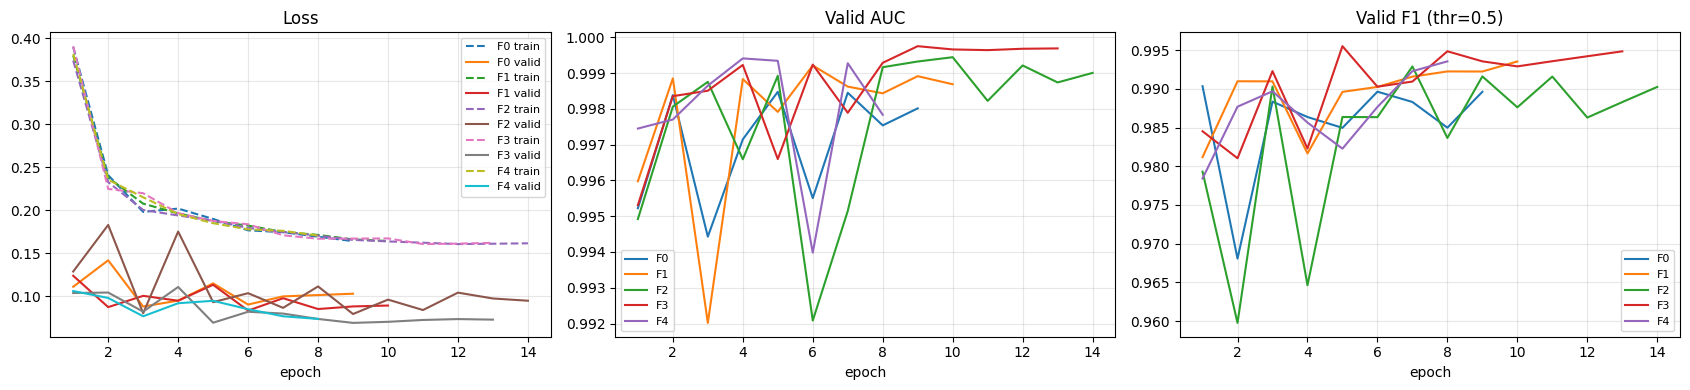

In [ ]:
# 학습 곡선
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for f, h in histories.items():
    axes[0].plot(h.epoch, h.tr_loss, '--', label=f'F{f} train')
    axes[0].plot(h.epoch, h.va_loss, '-',  label=f'F{f} valid')
    axes[1].plot(h.epoch, h.auc, label=f'F{f}')
    axes[2].plot(h.epoch, h.f1,  label=f'F{f}')
for ax, t in zip(axes, ['Loss', 'Valid AUC', 'Valid F1 (thr=0.5)']):
    ax.set_title(t); ax.set_xlabel('epoch'); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. 검증 (OOF) & Threshold 튜닝

평가지표가 Accuracy든 F1이든, 불균형 데이터에서는 0.5가 최적이 아닌 경우가 많습니다.
OOF(검증) 예측으로 **Accuracy / F1(macro)을 최대화하는 threshold**를 찾습니다.
> 대회 평가지표가 공지되어 있다면 `METRIC`을 그에 맞춰 바꾸세요.

OOF AUC           : 0.9989
@0.50  f1_macro  : 0.9780
@0.11  f1_macro  : 0.9867   ← best threshold

              precision    recall  f1-score   support

      NORMAL     0.9835    0.9769    0.9802      1341
   PNEUMONIA     0.9920    0.9943    0.9932      3875

    accuracy                         0.9898      5216
   macro avg     0.9878    0.9856    0.9867      5216
weighted avg     0.9898    0.9898    0.9898      5216



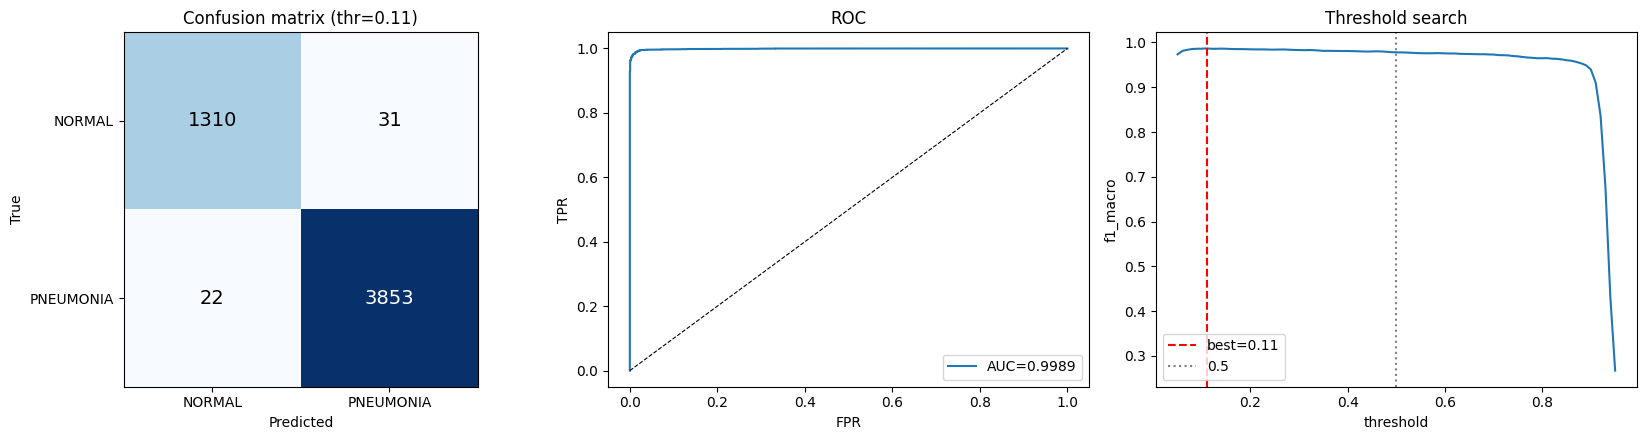

In [ ]:
oof = train_df.dropna(subset=['oof'])
y_true, y_prob = oof['label'].values, oof['oof'].values

METRIC = 'f1_macro'   # 'accuracy' | 'f1_macro' | 'f1'
def score_fn(y, p, metric=METRIC):
    if metric == 'accuracy': return accuracy_score(y, p)
    if metric == 'f1_macro': return f1_score(y, p, average='macro')
    return f1_score(y, p)

thrs = np.arange(0.05, 0.96, 0.01)
scores = [score_fn(y_true, (y_prob > t).astype(int)) for t in thrs]
BEST_THR = float(thrs[int(np.argmax(scores))])

print(f'OOF AUC           : {roc_auc_score(y_true, y_prob):.4f}')
print(f'@0.50  {METRIC:10s}: {score_fn(y_true, (y_prob > 0.5).astype(int)):.4f}')
print(f'@{BEST_THR:.2f}  {METRIC:10s}: {max(scores):.4f}   ← best threshold')
print()
print(classification_report(y_true, (y_prob > BEST_THR).astype(int), target_names=['NORMAL', 'PNEUMONIA'], digits=4))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
cm = confusion_matrix(y_true, (y_prob > BEST_THR).astype(int))
axes[0].imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, v, ha='center', va='center', fontsize=14, color='white' if v > cm.max()/2 else 'black')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['NORMAL', 'PNEUMONIA'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['NORMAL', 'PNEUMONIA'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title(f'Confusion matrix (thr={BEST_THR:.2f})')

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_true, y_prob):.4f}'); axes[1].plot([0, 1], [0, 1], 'k--', lw=.8)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC'); axes[1].legend()

axes[2].plot(thrs, scores); axes[2].axvline(BEST_THR, color='r', ls='--', label=f'best={BEST_THR:.2f}')
axes[2].axvline(0.5, color='gray', ls=':', label='0.5')
axes[2].set_xlabel('threshold'); axes[2].set_ylabel(METRIC); axes[2].set_title('Threshold search'); axes[2].legend()
plt.tight_layout(); plt.show()

## 7. 테스트 추론 (Fold 앙상블 + TTA) & 제출 파일

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

...

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

infer:   0%|          | 0/10 [00:00<?, ?it/s]

앙상블 수: 10 (모델 5 × TTA 2) | threshold=0.11
테스트 예측 분포:
label
PNEUMONIA    417
NORMAL       207
Name: count, dtype: int64


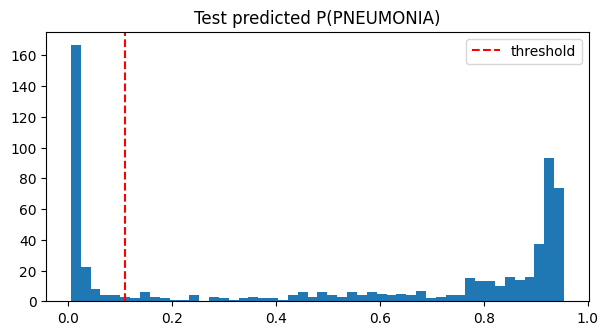

In [ ]:
tfs = [valid_tf, tta_zoom_tf] if CFG.USE_TTA else [valid_tf]
test_probs = []
for path in model_paths:
    model = build_model(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    for tf in tfs:
        loader = DataLoader(XrayDataset(test_df, tf, has_label=False), batch_size=CFG.BATCH_SIZE * 2,
                            shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
        test_probs.append(predict_proba(model, loader, has_label=False))
    del model; torch.cuda.empty_cache()

test_prob = np.mean(test_probs, axis=0)
test_df['prob'] = test_prob
test_df['label'] = (test_prob > BEST_THR).astype(int)

print(f'앙상블 수: {len(test_probs)} (모델 {len(model_paths)} × TTA {len(tfs)}) | threshold={BEST_THR:.2f}')
print('테스트 예측 분포:'); print(test_df['label'].value_counts().rename({0: 'NORMAL', 1: 'PNEUMONIA'}))

plt.figure(figsize=(7, 3.5))
plt.hist(test_prob, bins=50); plt.axvline(BEST_THR, color='r', ls='--', label='threshold')
plt.title('Test predicted P(PNEUMONIA)'); plt.legend(); plt.show()

In [ ]:
submission = sub_df[['file_name']].merge(test_df[['file_name', 'label']], on='file_name', how='left')
assert submission['label'].notna().all() and len(submission) == len(sub_df)
submission['label'] = submission['label'].astype(int)

save_path = os.path.join(CFG.OUT_DIR, f'submission_{CFG.MODEL_NAME}_{CFG.IMG_SIZE}_thr{BEST_THR:.2f}.csv')
submission.to_csv(save_path, index=False)
# 확률값도 저장해두면 나중에 다른 모델과 앙상블하거나 threshold만 바꿔 재제출할 때 편리
test_df[['file_name', 'prob']].to_csv(os.path.join(CFG.OUT_DIR, f'test_prob_{CFG.MODEL_NAME}.csv'), index=False)
print('saved →', save_path)
submission.head()

saved → ./outputs/submission_efficientnet_b0_384_thr0.11.csv


,file_name,label
0,test_0001.png,0
1,test_0002.png,0
2,test_0003.png,1
3,test_0004.png,1
4,test_0005.png,1


## 8. Grad-CAM — 모델이 어디를 보고 판단했는가?

의료 AI에서는 성능뿐 아니라 **근거 영역**이 중요합니다.
폐 실질(lung field)이 아닌 글자·마커·가장자리에 활성화가 몰린다면 shortcut learning을 의심해볼 수 있습니다.

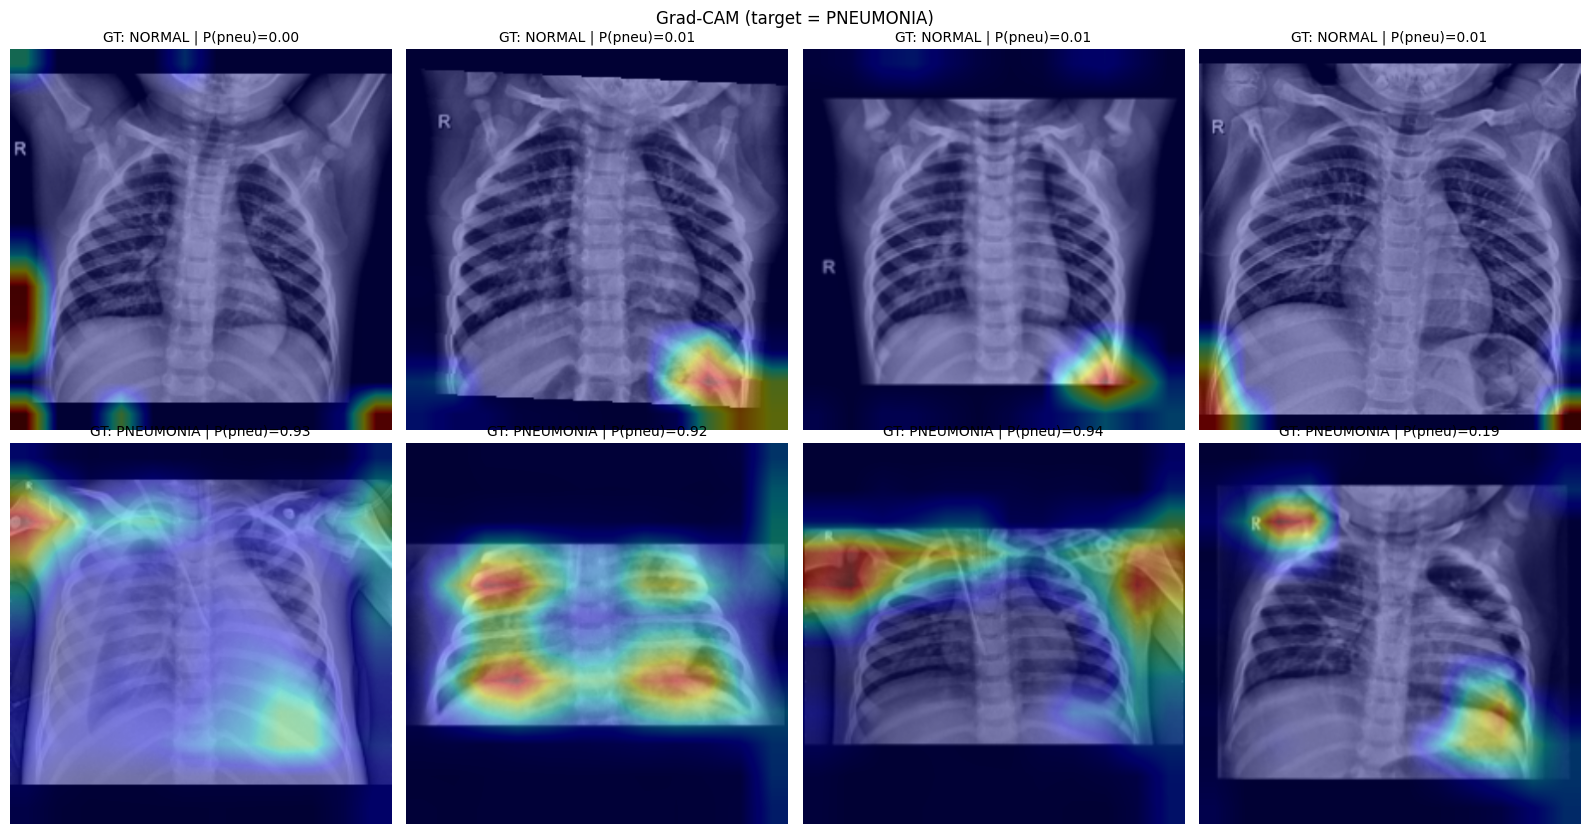

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model, self.acts, self.grads = model, None, None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))
    def __call__(self, x, cls=1):
        self.model.zero_grad()
        out = self.model(x)
        out[:, cls].sum().backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy(), F.softmax(out, 1)[0, 1].item()

def get_target_layer(model, name=CFG.MODEL_NAME):
    if name == 'efficientnet_b0': return model.features[-1]
    if name == 'resnet50':        return model.layer4[-1]
    if name == 'convnext_tiny':   return model.features[-1]
    if name == 'densenet121':     return model.features.denseblock4
    raise ValueError(name)

cam_model = build_model(pretrained=False).to(DEVICE)
cam_model.load_state_dict(torch.load(model_paths[0], map_location=DEVICE)); cam_model.eval()
gradcam = GradCAM(cam_model, get_target_layer(cam_model))

# 첫 번째 폴드 검증셋에서 정상/폐렴 각 4장
va0 = train_df[train_df['fold'] == folds[0]]
samples = pd.concat([va0[va0.label == 0].sample(4, random_state=1), va0[va0.label == 1].sample(4, random_state=1)])
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (_, r) in zip(axes.flat, samples.iterrows()):
    raw = load_xray(r.path)
    x = valid_tf(raw).unsqueeze(0).to(DEVICE).requires_grad_(True)
    cam, p = gradcam(x)
    base = cv2.resize(raw, (CFG.IMG_SIZE, CFG.IMG_SIZE))
    ax.imshow(base); ax.imshow(cam, cmap='jet', alpha=0.4)
    ax.set_title(f"GT: {['NORMAL','PNEUMONIA'][r.label]} | P(pneu)={p:.2f}", fontsize=10); ax.axis('off')
plt.suptitle('Grad-CAM (target = PNEUMONIA)'); plt.tight_layout(); plt.show()